<a href="https://colab.research.google.com/github/mohammedaslanshas/codomax-ds-internship/blob/main/Day16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Cleaning (from Day 7)
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# Organizing (from Day 7)
df = df[["Name", "Age", "Sex", "Pclass", "Survived", "Fare", "Embarked"]]
df = df.rename(columns={"Sex": "Gender", "Pclass": "Ticketclass"})

# Verify
print(df.shape)
print(df.isnull().sum())
df.head()

(891, 7)
Name           0
Age            0
Gender         0
Ticketclass    0
Survived       0
Fare           0
Embarked       0
dtype: int64


,Name,Age,Gender,Ticketclass,Survived,Fare,Embarked
0,"Braund, Mr. Owen Harris",22.0,male,3,0,7.2500,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female,1,1,71.2833,C
2,"Heikkinen, Miss. Laina",26.0,female,3,1,7.9250,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female,1,1,53.1000,S
4,"Allen, Mr. William Henry",35.0,male,3,0,8.0500,S


In [7]:
df["Gender_encoded"] = df["Gender"].map({"male": 0, "female": 1})

X = df[["Age", "Fare", "Ticketclass", "Gender_encoded"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168

Confusion Matrix:
 [[90 15]
 [20 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



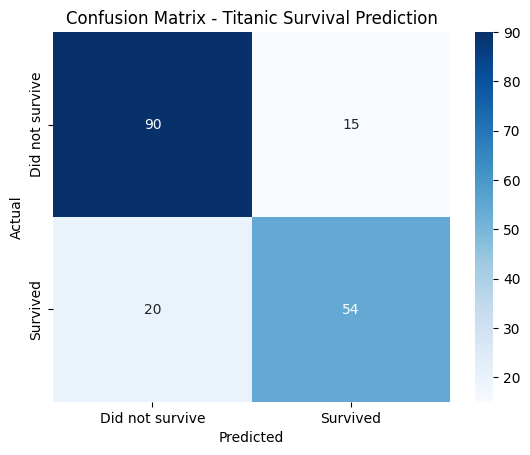

In [5]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did not survive","Survived"],
            yticklabels=["Did not survive","Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Titanic Survival Prediction")
plt.show()

In [6]:
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.3f}")

Age: -0.025
Fare: 0.001
Ticketclass: -0.996
Gender_encoded: 2.466
